# Завдання
1. Отримання вхідних даних із властивостями, заданими в ev_df;
2. Визначення показників якості та оптимізація моделі (вибір моделі залежно від
значення показника якості). Показник якості та спосіб оптимізації обрати самостійно.
3. Статистичне навчання поліноміальної моделі за методом найменших квадратів
(МНК – LSM) – поліноміальна регресія для вхідних даних, отриманих в п.1,2. Спосіб
реалізації МНК обрати самостійно;
4. Прогнозування (екстраполяцію) параметрів досліджуваного процесу за «навченою»
у п.5 моделлю на 0,5 інтервалу спостереження (об’єму вибірки);
5. Провести аналіз отриманих результатів та верифікацію розробленого скрипта.
6. Очищення вхідних даних від аномальних вимірів. Спосіб виявлення аномалій та
очищення обрати самостійно;
Здійснити розробку власного алгоритму статистичного навчання із нелінійною за
параметрами моделлю.

# Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import IsolationForest
from scipy import stats
from scipy.optimize import curve_fit
import warnings

warnings.filterwarnings("ignore")

# Load file

In [2]:
RANDOM_SEED = 42


def load_and_clean(path='data/ev_cars.xlsx', column_names=None):
    if column_names is None:
        column_names = ['manufacturer', 'model', 'year', 'price', 'km_age', 'date_added']
    df = pd.read_excel(path, names=None)
    # ensure required cols exist (try to coerce)
    df = df.rename(columns={c: c.strip() for c in df.columns})
    # keep only relevant columns if present
    for c in column_names:
        if c not in df.columns:
            raise ValueError(f"Missing column {c} in input file")
    df = df[column_names].copy()

    # types
    df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')
    df['year'] = pd.to_numeric(df['year'], errors='coerce').astype('Int64')

    # price cleanup
    df['price'] = df['price'].astype(str).str.replace('[$, ]', '', regex=True)
    df['price'] = df['price'].str.replace('\xa0', '', regex=False)
    df['price'] = df['price'].str.replace(' ', '', regex=False)
    df['price'] = pd.to_numeric(df['price'], errors='coerce')
    df['km_age'] = pd.to_numeric(df['km_age'], errors='coerce')
    df['vehicle_age'] = datetime.today().year - df['year']

    # drop rows with no date or no price
    df = df.dropna(subset=['date_added', 'price'])
    df = df.reset_index(drop=True)
    return df


# path to xlsx
path = 'data/ev_cars.xlsx'
ev_df = load_and_clean(path)

# 2. Anomaly detection & cleaning
#    - IQR for univariate outliers (price, km_age)
#    - IsolationForest for multivariate anomalies

In [3]:
def clean_anomalies(df, use_iforest=True):
    df_clean = df.copy()

    # Univariate IQR filter
    def iqr_filter(s, k=1.5):
        q1 = s.quantile(0.25);
        q3 = s.quantile(0.75)
        iqr = q3 - q1
        low = q1 - k * iqr;
        high = q3 + k * iqr
        return (s >= low) & (s <= high)

    mask_price = iqr_filter(df_clean['price'], k=1.5)
    mask_km = iqr_filter(df_clean['km_age'], k=1.5)
    df_clean = df_clean[mask_price & mask_km].copy()

    # Multivariate IsolationForest (price, km_age, vehicle_age)
    if use_iforest and len(df_clean) > 30:
        iso = IsolationForest(contamination=0.02, random_state=RANDOM_SEED)
        X = df_clean[['price', 'km_age', 'vehicle_age']].fillna(0).values
        preds = iso.fit_predict(X)  # -1 = outlier
        df_clean = df_clean[preds == 1].copy()

    df_clean = df_clean.reset_index(drop=True)
    return df_clean


df_clean = clean_anomalies(ev_df, use_iforest=True)
print(f"After cleaning: {len(df_clean)} rows")

After cleaning: 9046 rows


# 3. Train/validate polynomial model using LSM
##    - choose degree by TimeSeriesSplit CV optimizing RMSE
##    - LSM implementation via numpy.linalg.lstsq for final fit

In [4]:
def time_series_degree_selection(df, max_degree=5, n_splits=5, random_state=RANDOM_SEED):
    # Sort by date
    df_sorted = df.sort_values('date_added').reset_index(drop=True)
    X_base = df_sorted[['km_age', 'vehicle_age']].values
    y = df_sorted['price'].values
    tscv = TimeSeriesSplit(n_splits=n_splits)
    best = {'degree': None, 'rmse': np.inf}
    results = []
    for deg in range(1, max_degree + 1):
        rmses = []
        for train_idx, val_idx in tscv.split(X_base):
            X_train = X_base[train_idx];
            y_train = y[train_idx]
            X_val = X_base[val_idx];
            y_val = y[val_idx]
            poly = PolynomialFeatures(degree=deg, include_bias=True)
            Xt = poly.fit_transform(X_train)
            # Standardize to improve numeric stability
            scaler = StandardScaler().fit(Xt)
            Xt_s = scaler.transform(Xt)
            # LSM via numpy
            coef, *_ = np.linalg.lstsq(Xt_s, y_train, rcond=None)
            # predict
            Xv = poly.transform(X_val)
            Xv_s = scaler.transform(Xv)
            y_pred = Xv_s.dot(coef)
            rmses.append(np.sqrt(mean_squared_error(y_val, y_pred)))
        mean_rmse = np.mean(rmses)
        results.append((deg, mean_rmse))
        if mean_rmse < best['rmse']:
            best = {'degree': deg, 'rmse': mean_rmse}
    return best, results


# degree selection
best, all_results = time_series_degree_selection(df_clean, max_degree=5, n_splits=5)
print("Degree CV results:", all_results)
print("Best degree:", best)


def fit_polynomial_lsm(df, degree):
    # final fit on all data using numpy.linalg.lstsq
    X = df[['km_age', 'vehicle_age']].values
    y = df['price'].values
    poly = PolynomialFeatures(degree=degree, include_bias=True)
    Xpoly = poly.fit_transform(X)
    # scale for stability (we'll store scaler and scale coefficients appropriately)
    scaler = StandardScaler().fit(Xpoly)
    Xs = scaler.transform(Xpoly)
    coef, *_ = np.linalg.lstsq(Xs, y, rcond=None)

    # for predictions we need poly, scaler, coef
    def predict(X_new):
        Xn = np.array(X_new)
        P = poly.transform(Xn)
        Ps = scaler.transform(P)
        return Ps.dot(coef)

    # compute metrics on training set
    y_pred = predict(X)
    rmse = np.sqrt(mean_squared_error(y, y_pred))
    r2 = r2_score(y, y_pred)
    return {'poly': poly, 'scaler': scaler, 'coef': coef, 'predict': predict, 'rmse': rmse, 'r2': r2}


# fit polynomial LSM
deg = best['degree']
poly_model = fit_polynomial_lsm(df_clean, degree=deg)
print(f"Polynomial LSM (deg={deg}) train RMSE={poly_model['rmse']:.2f}, R2={poly_model['r2']:.3f}")

Degree CV results: [(1, 21263.471191455767), (2, 21284.119659185606), (3, 21279.19442683096), (4, 21278.84271741421), (5, 21278.603562423872)]
Best degree: {'degree': 1, 'rmse': 21263.471191455767}
Polynomial LSM (deg=1) train RMSE=21276.66, R2=-3.620


# 4. Nonlinear parametric model (власний алгоритм)
## -    Price model example: price = A * (km_age + eps)^(-B) * exp(-C*vehicle_age) + D
## -    Fit via scipy.optimize.curve_fit (Левенберг - Маркардт)

In [5]:
def nonlinear_model_func(xdata, A, B, C, D):
    """
    xdata: array shape (N,2) where columns = [km_age, vehicle_age]
    returns: array shape (N,)
    """
    xdata = np.asarray(xdata, dtype=float)
    if xdata.ndim == 1:
        # if someone passes (2,) vector -> reshape to (1,2)
        xdata = xdata.reshape(1, -1)
    km = xdata[:, 0]
    veh = xdata[:, 1]
    eps = 1e-3
    # safe vectorized ops
    return A * (km + eps) ** (-B) * np.exp(-C * veh) + D


def fit_nonlinear_model(df):
    # ensure numeric and drop NaNs
    df = df.copy()
    df['km_age'] = pd.to_numeric(df['km_age'], errors='coerce')
    df['vehicle_age'] = pd.to_numeric(df['vehicle_age'], errors='coerce')
    df['price'] = pd.to_numeric(df['price'], errors='coerce')
    df = df.dropna(subset=['km_age', 'vehicle_age', 'price']).reset_index(drop=True)

    X = df[['km_age', 'vehicle_age']].values.astype(float)
    y = df['price'].values.astype(float)

    # diagnostic prints (you can comment out later)
    print("fit_nonlinear_model: X.shape =", X.shape, "y.shape =", y.shape)
    print("dtypes:", X.dtype, y.dtype)
    # initial guesses and bounds
    p0 = [1e5, 0.2, 0.05, 1000.0]  # A, B, C, D
    bounds = (0, np.inf)

    try:
        popt, pcov = curve_fit(
            nonlinear_model_func,
            X, y,
            p0=p0,
            bounds=bounds,
            maxfev=200000
        )
    except Exception as e:
        print("curve_fit failed:", e)
        popt = np.array(p0, dtype=float)
        pcov = np.zeros((4, 4))

    def predict(X_new):
        Xn = np.asarray(X_new, dtype=float)
        if Xn.ndim == 1:
            Xn = Xn.reshape(1, -1)
        return nonlinear_model_func(Xn, *popt)

    y_pred = predict(X)
    rmse = np.sqrt(mean_squared_error(y, y_pred))
    r2 = r2_score(y, y_pred)

    return {'params': popt, 'cov': pcov, 'predict': predict, 'rmse': rmse, 'r2': r2}


# fit nonlinear param model
nonlin_model = fit_nonlinear_model(df_clean)
print("Nonlinear model params:", nonlin_model['params'])
print(f"Nonlinear model RMSE={nonlin_model['rmse']:.2f}, R2={nonlin_model['r2']:.3f}")

# choose best by RMSE
if nonlin_model['rmse'] < poly_model['rmse']:
    chosen = ('nonlinear', nonlin_model)
else:
    chosen = ('polynomial', poly_model)
print("Chosen model:", chosen[0])

fit_nonlinear_model: X.shape = (9046, 2) y.shape = (9046,)
dtypes: float64 float64
Nonlinear model params: [3.72687657e+04 9.73511699e-13 1.15391183e-01 1.69138800e-06]
Nonlinear model RMSE=7065.75, R2=0.490
Chosen model: nonlinear


# 5. Extrapolation: forecast on 0.5*n future samples

In [6]:
def extrapolate_and_predict(df, model_predict, n_future=None):
    n = len(df)
    if n_future is None:
        n_future = int(0.5 * n)
    # create km_age values beyond current max up to +20% or +50k km whichever larger
    max_km = df['km_age'].max()
    future_km = np.linspace(max_km * 1.01, max_km * 1.4 + 50000, n_future)
    # vehicle_age: we assume future listings within same year distribution -> sample existing vehicle_age distribution (or linearly increase)
    # simple approach: keep vehicle_age same as median
    median_age = int(df['vehicle_age'].median())
    future_vehicle_age = np.full(n_future, median_age)
    X_future = np.column_stack([future_km, future_vehicle_age])
    y_future_pred = model_predict(X_future)
    df_future = pd.DataFrame({'km_age': future_km, 'vehicle_age': future_vehicle_age, 'price_pred': y_future_pred})
    return df_future


# extrapolate
df_future = extrapolate_and_predict(df_clean, chosen[1]['predict'], n_future=int(0.5 * len(df_clean)))
# evaluate predicted future statistics
print("Future predictions sample:\n", df_future.head())

# Save results
df_clean.to_excel("data/ev_cleaned.xlsx", index=False)
df_future.to_excel("data/ev_future_predictions.xlsx", index=False)

Future predictions sample:
           km_age  vehicle_age    price_pred
0  237350.000000            5  20930.337877
1  237381.324635            5  20930.337877
2  237412.649270            5  20930.337877
3  237443.973905            5  20930.337877
4  237475.298540            5  20930.337877


# Plots

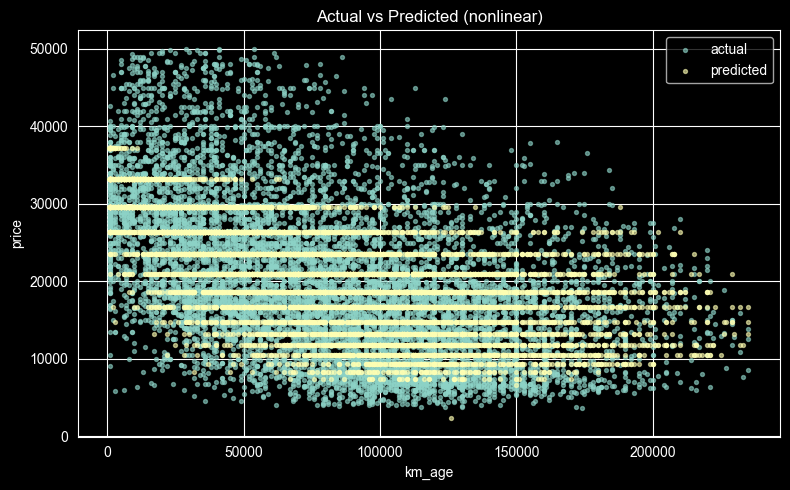

Train RMSE: 7065.750533736688
Train R2: 0.49047561000720696


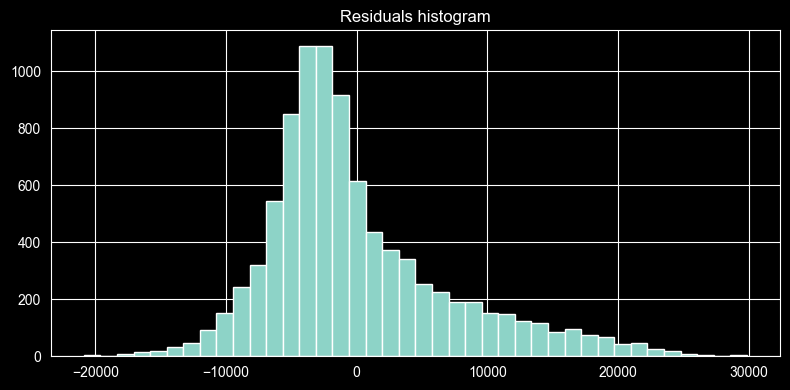

In [7]:
def run_plots():
    # Plots: actual vs predicted on train set
    Xtrain = df_clean[['km_age', 'vehicle_age']].values
    ytrain = df_clean['price'].values
    y_pred_train = chosen[1]['predict'](Xtrain)
    plt.figure(figsize=(8, 5))
    plt.scatter(df_clean['km_age'], ytrain, s=8, alpha=0.6, label='actual')
    plt.scatter(df_clean['km_age'], y_pred_train, s=8, alpha=0.6, label='predicted')
    plt.xlabel('km_age');
    plt.ylabel('price');
    plt.title(f'Actual vs Predicted ({chosen[0]})')
    plt.legend();
    plt.tight_layout();
    plt.show()
    # residuals
    residuals = ytrain - y_pred_train
    print("Train RMSE:", np.sqrt(mean_squared_error(ytrain, y_pred_train)))
    print("Train R2:", r2_score(ytrain, y_pred_train))
    # residual diagnostics plot
    plt.figure(figsize=(8, 4))
    plt.hist(residuals, bins=40)
    plt.title('Residuals histogram');
    plt.tight_layout();
    plt.show()
    # Return dict
    return {
        'df_clean': df_clean,
        'poly_model': poly_model,
        'nonlin_model': nonlin_model,
        'chosen': chosen,
        'df_future': df_future
    }


result = run_plots()